# Amazon Reviews Sentiment Analysis – Data Exploration

This notebook:

- Loads the Amazon JSONL dataset

- Extracts review text and numeric ratings (1–5)

- Converts ratings into sentiment categories

- Performs exploratory data analysis (EDA)

- Analyzes class distribution

- Analyzes word-level review length

- Detects outliers using box plots (IQR method)

- Creates stratified train/validation/test splits


In [33]:
import json
import os
from tqdm import tqdm

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split


In [34]:
DATA_PATH = "d:\\Masters\\Python\\CaseStudy\\amazon-sentiment-analysis\\data_raw\\reviews.json" 
print("Dataset path:", DATA_PATH)

Dataset path: d:\Masters\Python\CaseStudy\amazon-sentiment-analysis\data_raw\reviews.json


Load JSONL Dataset


In [35]:
def load_amazon_reviews(filepath):
    texts = []
    ratings = []

    with open(filepath, 'r', encoding='utf-8') as f:
        for line in tqdm(f):
            review = json.loads(line)

            if "reviewText" in review and "overall" in review:
                texts.append(review["reviewText"])
                ratings.append(int(review["overall"]))

    df = pd.DataFrame({
        "review_text": texts,
        "rating": ratings
    })

    return df


df = load_amazon_reviews(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()


194439it [00:00, 255287.16it/s]


Dataset shape: (194439, 2)


,review_text,rating
0,They look good and stick good! I just don't li...,4
1,These stickers work like the review says they ...,5
2,These are awesome and make my phone look so st...,5
3,Item arrived in great time and was in perfect ...,4
4,"awesome! stays on, and looks great. can be use...",5


In [36]:
rating_to_sentiment = {
    1: "very_negative",
    2: "negative",
    3: "neutral",
    4: "positive",
    5: "very_positive"
}

df["sentiment"] = df["rating"].map(rating_to_sentiment)

df.head()


,review_text,rating,sentiment
0,They look good and stick good! I just don't li...,4,positive
1,These stickers work like the review says they ...,5,very_positive
2,These are awesome and make my phone look so st...,5,very_positive
3,Item arrived in great time and was in perfect ...,4,positive
4,"awesome! stays on, and looks great. can be use...",5,very_positive


In [37]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 194439 entries, 0 to 194438
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   review_text  194439 non-null  object
 1   rating       194439 non-null  int64 
 2   sentiment    194439 non-null  object
dtypes: int64(1), object(2)
memory usage: 4.5+ MB


,rating
count,194439.000000
mean,4.129912
std,1.222499
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


In [38]:
df.isnull().sum()


review_text    0
rating         0
sentiment      0
dtype: int64

Sentiment Distribution

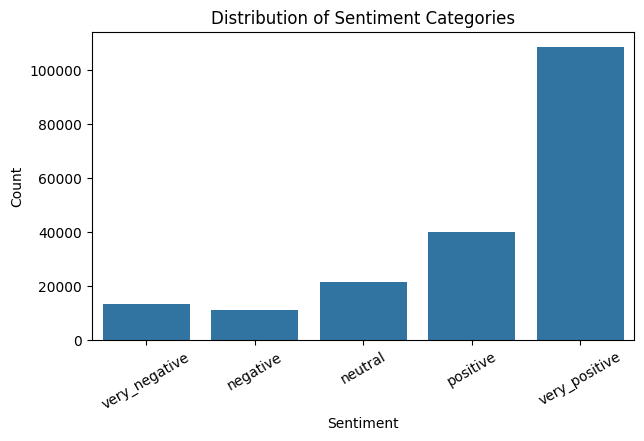

In [39]:
plt.figure(figsize=(7,4))
sns.countplot(x="sentiment", data=df,
              order=["very_negative","negative","neutral","positive","very_positive"])
plt.title("Distribution of Sentiment Categories")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.show()


In [40]:
sentiment_distribution = (
    df["sentiment"]
    .value_counts(normalize=True)
    .loc[["very_negative","negative","neutral","positive","very_positive"]]
    * 100
)

print("Sentiment Percentage Distribution (%):")
print(sentiment_distribution)


Sentiment Percentage Distribution (%):
sentiment
very_negative     6.829391
negative          5.690216
neutral          11.026080
positive         20.568404
very_positive    55.885908
Name: proportion, dtype: float64


Word Count Calculation

In [41]:
df["word_count"] = df["review_text"].apply(lambda x: len(x.split()))

df[["word_count"]].describe()



,word_count
count,194439.000000
mean,91.595112
std,134.858032
min,0.000000
25%,28.000000
50%,48.000000
75%,100.000000
max,5263.000000


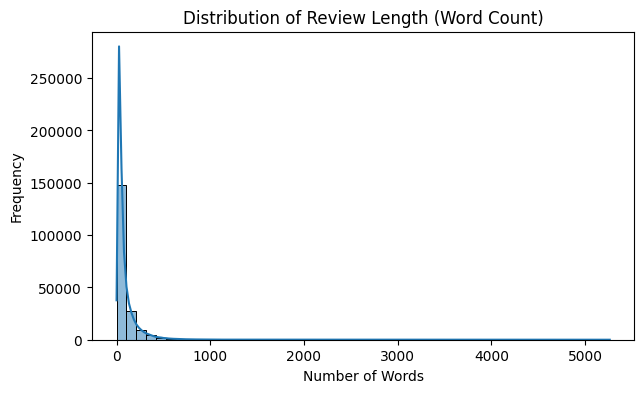

In [42]:
plt.figure(figsize=(7,4))
sns.histplot(df["word_count"], bins=50, kde=True)
plt.title("Distribution of Review Length (Word Count)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()


Right skewed distribution

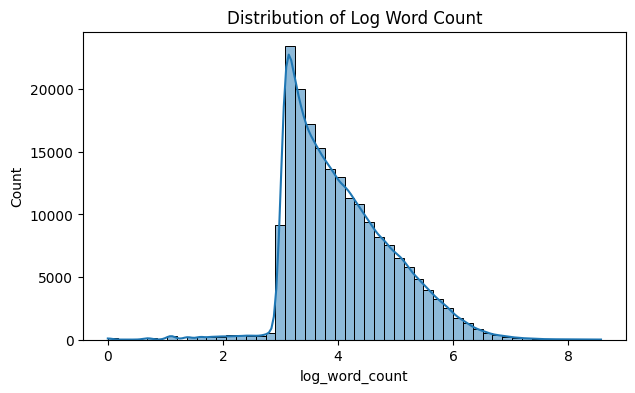

In [43]:
df["log_word_count"] = np.log1p(df["word_count"])

plt.figure(figsize=(7,4))
sns.histplot(df["log_word_count"], bins=50, kde=True)
plt.title("Distribution of Log Word Count")
plt.show()


Outlier Detection 

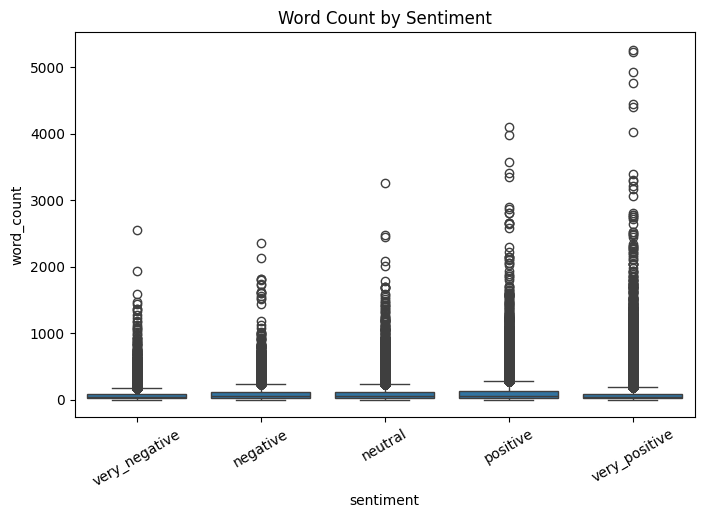

In [48]:
plt.figure(figsize=(8,5))
sns.boxplot(x="sentiment", y="word_count", data=df,
            order=["very_negative","negative","neutral","positive","very_positive"])
plt.xticks(rotation=30)
plt.title("Word Count by Sentiment")
plt.show()


In [49]:
Q1 = df["word_count"].quantile(0.25)
Q3 = df["word_count"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["word_count"] < lower_bound) |
    (df["word_count"] > upper_bound)
]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Outliers:", len(outliers))


Lower Bound: -80.0
Upper Bound: 208.0
Number of Outliers: 19036


The IQR method identified 19,036 reviews as statistical outliers based on review length. However, since these represent genuine detailed user reviews rather than erroneous data, they were retained in the dataset.

Train / Validation / Test Split

In [46]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["sentiment"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["sentiment"],
    random_state=42
)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)


Train shape: (155551, 5)
Validation shape: (19444, 5)
Test shape: (19444, 5)


In [47]:
os.makedirs("../data/processed", exist_ok=True)

train_df.to_csv("../data/processed/train.csv", index=False)
val_df.to_csv("../data/processed/val.csv", index=False)
test_df.to_csv("../data/processed/test.csv", index=False)

print("Processed datasets saved successfully.")


Processed datasets saved successfully.
